In [2]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 30.8 MB/s eta 0:00:00


In [3]:
from pathlib import Path
import pydicom
import matplotlib.pyplot as plt
import numpy as np

In [6]:
dicom_file = pydicom.dcmread("/content/ID_0000_AGE_0060_CONTRAST_1_CT.dcm")


In [7]:
print(dicom_file)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 194
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.14519.5.2.1.7777.9002.108821836759549281694712274169
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.40.0.13.1.1.1
(0002,0013) Implementation Version Name         SH: 'dcm4che-1.4.31'
-------------------------------------------------
(0008,0000) Group Length                        UL: 430
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL']
(0008,0016) SOP Class UID                       UI: CT Image Storage
(0008,0018) SOP Instance UID                    UI: 1.3.6.1.4.1.14519.5.2.1.7777.9002.1088218367595492

In [8]:
dicom_file[0x0028, 0x0010]

(0028,0010) Rows                                US: 512

In [9]:
dicom_file.Rows

512

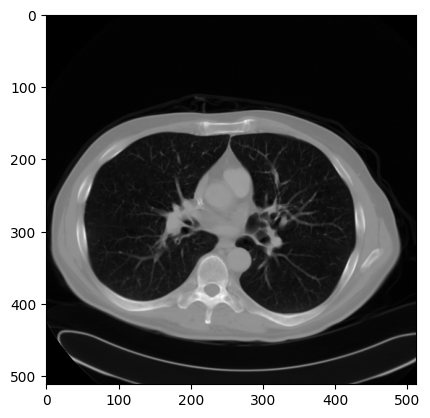

In [10]:
ct = dicom_file.pixel_array
plt.figure()
plt.imshow(ct, cmap='gray')
plt.show()

In [18]:
path_to_head_mri = Path("/content/dicom/")

In [19]:
all_files = list(path_to_head_mri.glob("*"))

In [20]:
all_files

[PosixPath('/content/dicom/ID_0065_AGE_0082_CONTRAST_0_CT.dcm'),
 PosixPath('/content/dicom/ID_0074_AGE_0074_CONTRAST_0_CT.dcm'),
 PosixPath('/content/dicom/ID_0081_AGE_0058_CONTRAST_0_CT.dcm'),
 PosixPath('/content/dicom/ID_0095_AGE_0071_CONTRAST_0_CT.dcm'),
 PosixPath('/content/dicom/ID_0036_AGE_0074_CONTRAST_1_CT.dcm'),
 PosixPath('/content/dicom/ID_0086_AGE_0073_CONTRAST_0_CT.dcm'),
 PosixPath('/content/dicom/ID_0043_AGE_0069_CONTRAST_1_CT.dcm'),
 PosixPath('/content/dicom/ID_0082_AGE_0047_CONTRAST_0_CT.dcm'),
 PosixPath('/content/dicom/ID_0056_AGE_0083_CONTRAST_0_CT.dcm'),
 PosixPath('/content/dicom/ID_0031_AGE_0039_CONTRAST_1_CT.dcm'),
 PosixPath('/content/dicom/ID_0034_AGE_0061_CONTRAST_1_CT.dcm'),
 PosixPath('/content/dicom/ID_0029_AGE_0078_CONTRAST_1_CT.dcm'),
 PosixPath('/content/dicom/ID_0058_AGE_0082_CONTRAST_0_CT.dcm'),
 PosixPath('/content/dicom/ID_0011_AGE_0061_CONTRAST_1_CT.dcm'),
 PosixPath('/content/dicom/ID_0050_AGE_0074_CONTRAST_0_CT.dcm'),
 PosixPath('/content/dico

In [25]:
mri_data = []

for path in all_files:
    path = Path(path)  # ensure it's a Path object
    if path.is_file() and path.suffix == '.dcm':
        data = pydicom.dcmread(path)
        mri_data.append(data)


In [26]:
for slice in mri_data[:5]:
  print(slice.SliceLocation)

-150
-214.500
-142
-154.250000
-321


In [27]:
mri_data_ordered = sorted(mri_data, key=lambda slice: slice.SliceLocation)

for slice in mri_data_ordered[:5]:
  print(slice.SliceLocation)

-1168.4
-948.5
-948.2
-918.5
-901


In [28]:
full_volume = []
for slice in mri_data_ordered:
  full_volume.append(slice.pixel_array)

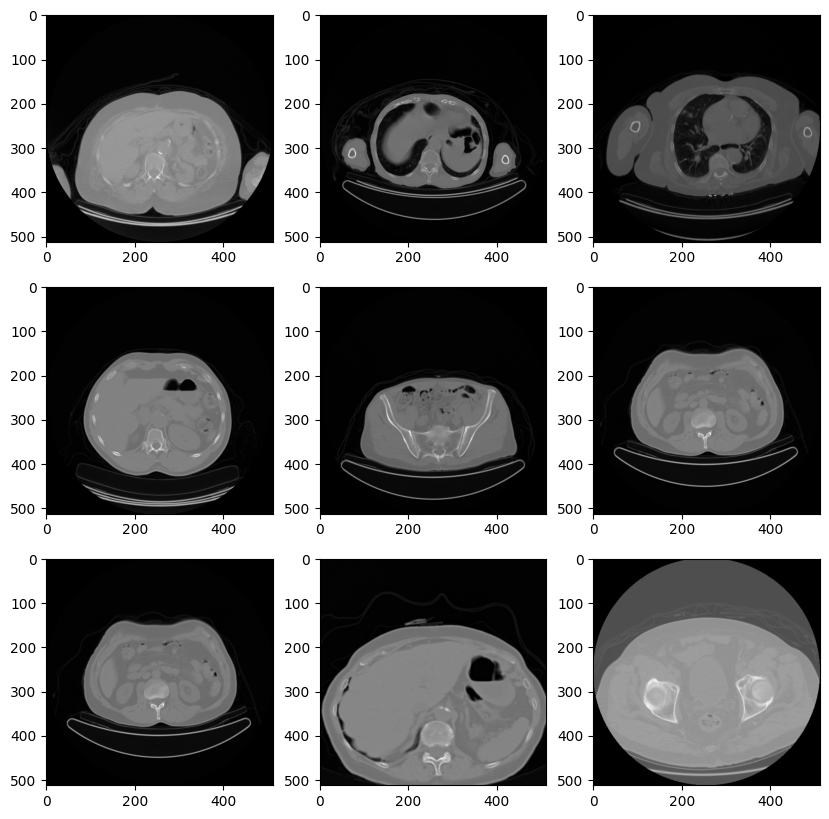

In [31]:
fig, axis = plt.subplots(3,3, figsize=(10,10))
slice_counter = 0
for i in range(3):
  for j in range(3):
    axis[i,j].imshow(full_volume[slice_counter], cmap='gray')
    # axis[i,j].axis('off')
    slice_counter += 1

In [32]:
!pip install SimpleITK

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 MB 8.4 MB/s eta 0:00:00


In [33]:
import SimpleITK as sitk

In [34]:
series_ids = sitk.ImageSeriesReader.GetGDCMSeriesIDs("/content/dicom/")
print(series_ids)

('1.3.6.1.4.1.14519.5.2.1.3023.4012.102289758600639081883682341599', '1.3.6.1.4.1.14519.5.2.1.3023.4012.111970507245102440072981773069', '1.3.6.1.4.1.14519.5.2.1.3023.4012.154470741269083988898569715734', '1.3.6.1.4.1.14519.5.2.1.3023.4012.251486101984782457779149100338', '1.3.6.1.4.1.14519.5.2.1.3023.4012.281222452204153314922270968637', '1.3.6.1.4.1.14519.5.2.1.3023.4012.297267439816180432188742253053', '1.3.6.1.4.1.14519.5.2.1.3023.4012.513523794062613324810980652054', '1.3.6.1.4.1.14519.5.2.1.3023.4012.648531603410109839170055154074', '1.3.6.1.4.1.14519.5.2.1.3023.4012.695837418985624676340861607694', '1.3.6.1.4.1.14519.5.2.1.6450.4012.153444090734536905415278769671', '1.3.6.1.4.1.14519.5.2.1.6450.4012.175016803370372621275285549100', '1.3.6.1.4.1.14519.5.2.1.6450.4012.185965196167856618864777448062', '1.3.6.1.4.1.14519.5.2.1.6450.4012.200234714530375524999580843628', '1.3.6.1.4.1.14519.5.2.1.6450.4012.249320450296411760831322037482', '1.3.6.1.4.1.14519.5.2.1.6450.4012.288687105792

In [35]:
series_file_names = sitk.ImageSeriesReader.GetGDCMSeriesFileNames("/content/dicom/", series_ids[0])
series_file_names

('/content/dicom/ID_0078_AGE_0066_CONTRAST_0_CT.dcm',)

In [36]:
series_reader = sitk.ImageSeriesReader()
series_reader.SetFileNames(series_file_names)

In [37]:
image_data = series_reader.Execute()

In [38]:
head_mri = sitk.GetArrayFromImage(image_data)

In [39]:
head_mri.shape

(1, 512, 512)

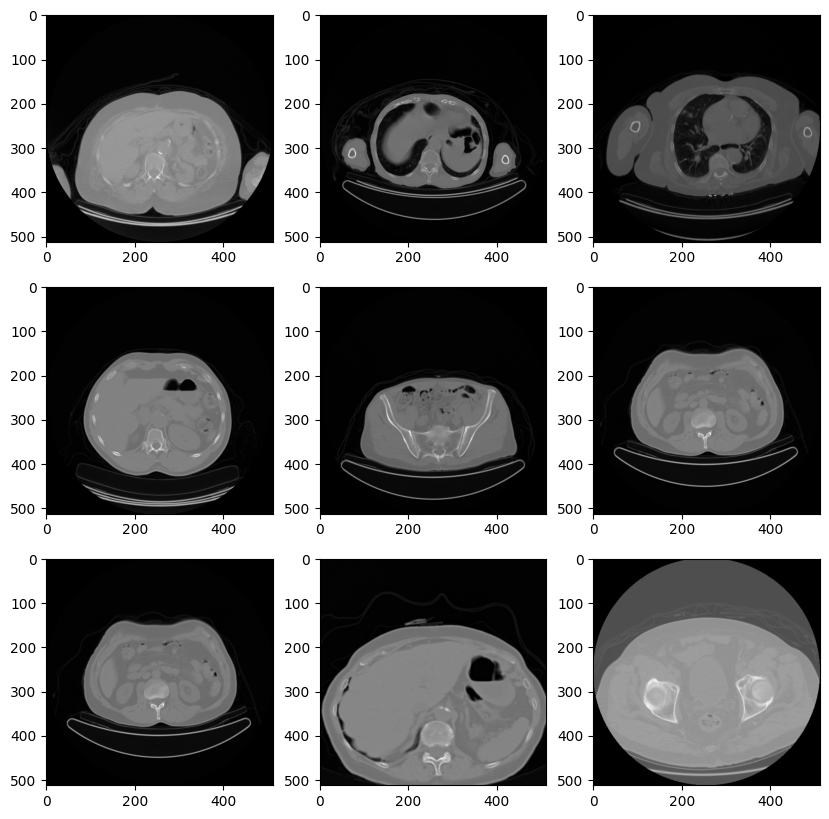

In [40]:
fig, axis = plt.subplots(3,3, figsize=(10,10))
slice_counter = 0
for i in range(3):
  for j in range(3):
    axis[i,j].imshow(full_volume[slice_counter], cmap='gray')
    # axis[i,j].axis('off')
    slice_counter += 1